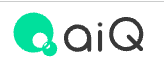

[disclaimer](./disclaimer.txt/)

# Altanative Data Evaluator

Data Handler の中で保持されているオルタナティブデータについて評価を行うためのコンポネントです。<br>
KPI相関分析、分位ポートフォリオ、機械学習モデルを使ったKPIの予測値算出、そして予測値のパフォーマンス評価を行います。

In [1]:
# サンプル用のライブラリをインポート
import sys
import numpy as np
import pandas as pd
import plotly.io

for_html = False
if for_html == True:
    plotly.offline.init_notebook_mode()
else:
    plotly.io.renderers.default = 'iframe'

sys.path.append('..')
from utils.shortcut import single_dataset as sc

## 0. インスタンスの作り方

### ライブラリのインポート
`DAL`（データハンドラー）と`AltDataEvaluator`をインポートします.

In [2]:
from aiq_strategy_robot.data.data_accessor import DAL
from aiq_strategy_robot.evaluator import AltDataEvaluator

### データハンドラーのセットアップ
データハンドラーに評価対象データをロードし、データ変換を行います. <br>
サンプルではデータロード・変換処理の詳細は割愛します.

In [3]:
sdh = DAL()

sc.register_and_transform_for_sample(sdh, data_dir='../data')

# データソースの確認
display(sdh.extract_definition)

# メソッドチェーンを確認
dfmc = sdh.transform.show_method_chain(ret_df=True)

# 変数IDを取得
alt_W_shift_0_sma12_logdiff_ids = sdh.transform.get_definition(pids=dfmc.iloc[0].name).variable_id.to_list()
alt_W_shift_1_sma12_logdiff_ids = sdh.transform.get_definition(pids=dfmc.iloc[1].name).variable_id.to_list()
alt_W_shift_2_sma12_logdiff_ids = sdh.transform.get_definition(pids=dfmc.iloc[2].name).variable_id.to_list()
alt_W_shift_3_sma12_logdiff_ids = sdh.transform.get_definition(pids=dfmc.iloc[3].name).variable_id.to_list()
alt_W_shift_4_sma12_logdiff_ids = sdh.transform.get_definition(pids=dfmc.iloc[4].name).variable_id.to_list()
alt_W_shift_5_sma12_logdiff_ids = sdh.transform.get_definition(pids=dfmc.iloc[5].name).variable_id.to_list()
alt_W_shift_6_sma12_logdiff_ids = sdh.transform.get_definition(pids=dfmc.iloc[6].name).variable_id.to_list()
alt_W_shift_7_sma12_logdiff_ids = sdh.transform.get_definition(pids=dfmc.iloc[7].name).variable_id.to_list()
alt_W_shift_8_sma12_logdiff_ids = sdh.transform.get_definition(pids=dfmc.iloc[8].name).variable_id.to_list()
close_ret = sdh.transform.get_definition(pids=dfmc.iloc[-1].name).variable_id[0]

,category,data_source,source,table,alias,tickers,index,start_datetime,end_datetime
data_id,,,,,,,,,
1,RawData,external,sample,Unknown,aiq_pos_csmr_goods,"[1301-JP, 1332-JP, 1333-JP, 1379-JP, 1380-JP, ...","[ticker, datetime]",2008-03-16 00:00:00,2024-03-03 00:00:00
2,RawData,external,sample,Unknown,market,"[1301-JP, 1332-JP, 1333-JP, 1379-JP, 1380-JP, ...","[ticker, datetime]",2008-03-14 00:00:00,2024-03-22 00:00:00


,data_id,root,step_001,step_002,step_003
proc_id,,,,,
da755bea,1,"resample(rule=""W"", func=""mean"", origin=""start_day"")",log_diff(periods=52),-,-
0268f932,1,shift(periods=1),"resample(rule=""W"", func=""mean"", origin=""start_day"")",sma(periods=12),log_diff(periods=52)
2af49e24,1,shift(periods=2),"resample(rule=""W"", func=""mean"", origin=""start_day"")",sma(periods=12),log_diff(periods=52)
573ab880,1,shift(periods=3),"resample(rule=""W"", func=""mean"", origin=""start_day"")",sma(periods=12),log_diff(periods=52)
5e6ea946,1,shift(periods=4),"resample(rule=""W"", func=""mean"", origin=""start_day"")",sma(periods=12),log_diff(periods=52)
0e9f831a,1,shift(periods=5),"resample(rule=""W"", func=""mean"", origin=""start_day"")",sma(periods=12),log_diff(periods=52)
d20f220a,1,shift(periods=6),"resample(rule=""W"", func=""mean"", origin=""start_day"")",sma(periods=12),log_diff(periods=52)
e25fd4db,1,shift(periods=7),"resample(rule=""W"", func=""mean"", origin=""start_day"")",sma(periods=12),log_diff(periods=52)
94aab41e,1,shift(periods=8),"resample(rule=""W"", func=""mean"", origin=""start_day"")",sma(periods=12),log_diff(periods=52)


### AltDataEvaluatorの初期化
セットアップ済みのハンドラーで`AltDataEvaluaor`のインスタンスを作成します.

In [4]:
ade = AltDataEvaluator(sdh)


## 1. KPI 相関を取る例

KPI及びオルタナティブデータの変数IDを指定し、相関計算します.

In [5]:
features = sdh.get_raw_data(1).columns.to_list()
features

['pos_sales', 'share', 'unit_price', 'unit_price_vs_ind']

### Pooling

In [8]:
rho_pool = pd.DataFrame()
rho_pool['n_shift=0, sma=12, diff1'] = ade.compu_rho(alt_W_shift_0_sma12_logdiff_ids, close_ret, rename_features=features)
rho_pool['n_shift=1, sma=12, diff1'] = ade.compu_rho(alt_W_shift_1_sma12_logdiff_ids, close_ret, rename_features=features)
rho_pool['n_shift=2, sma=12, diff1'] = ade.compu_rho(alt_W_shift_2_sma12_logdiff_ids, close_ret, rename_features=features)
rho_pool['n_shift=3, sma=12, diff1'] = ade.compu_rho(alt_W_shift_3_sma12_logdiff_ids, close_ret, rename_features=features)
rho_pool['n_shift=4, sma=12, diff1'] = ade.compu_rho(alt_W_shift_4_sma12_logdiff_ids, close_ret, rename_features=features)
rho_pool['n_shift=5, sma=12, diff1'] = ade.compu_rho(alt_W_shift_5_sma12_logdiff_ids, close_ret, rename_features=features)
rho_pool['n_shift=6, sma=12, diff1'] = ade.compu_rho(alt_W_shift_6_sma12_logdiff_ids, close_ret, rename_features=features)
rho_pool['n_shift=7, sma=12, diff1'] = ade.compu_rho(alt_W_shift_7_sma12_logdiff_ids, close_ret, rename_features=features)
rho_pool['n_shift=8, sma=12, diff1'] = ade.compu_rho(alt_W_shift_8_sma12_logdiff_ids, close_ret, rename_features=features)

display(rho_pool.xs('t-val', level=1).sort_values(rho_pool.columns[0], ascending=False))

Variables being created: 100%|██████████| 16/16 [00:02<00:00,  6.28it/s]


,"n_shift=0, sma=12, diff1","n_shift=1, sma=12, diff1","n_shift=2, sma=12, diff1","n_shift=3, sma=12, diff1","n_shift=4, sma=12, diff1","n_shift=5, sma=12, diff1","n_shift=6, sma=12, diff1","n_shift=7, sma=12, diff1","n_shift=8, sma=12, diff1"
pos_sales,3.988608,6.558211,6.288663,6.414349,6.387721,6.118143,5.487600,5.382758,4.938323
share,2.337484,3.512375,3.308825,3.092316,3.389276,3.285500,3.120749,3.122486,3.040014
unit_price,-0.746125,0.857340,1.055606,1.200542,1.098926,1.213180,1.053002,0.869211,0.516296
unit_price_vs_ind,-0.984050,-1.393382,-1.286122,-1.087548,-1.090011,-1.084866,-1.408818,-1.514960,-1.700693


### by Ticker

In [13]:
rho_time = ade.compu_rho(alt_W_shift_1_sma12_logdiff_ids, close_ret, by='ticker', rename_features=features)
rho_time.T.xs('t-val', level=1).sort_values('pos_sales', ascending=False).head()

,pos_sales,share,unit_price,unit_price_vs_ind
ticker,,,,
2281-JP,3.505645,3.369123,2.137623,1.162140
5194-JP,3.188901,3.761244,2.029955,1.704698
2212-JP,3.056784,1.782047,1.017993,-0.322797
2884-JP,2.914284,1.194342,0.175939,1.497298
2266-JP,2.466982,0.240809,-1.466657,-0.826028


## 2. 分位ポートフォリオ

In [9]:
# define the parameters for factor choice.
nq = 3
exe_cost = 0.0005

# Use pre-created variable ID
pos_sales = alt_W_shift_1_sma12_logdiff_ids[0]
ret = close_ret

In [10]:
dfqret, stats, dfsigqt = ade.q_backtest(
    pos_sales,
    ret,
    nq=nq,
    exe_cost=exe_cost,
    plot=True,
    stats=True
)

,cum.Ret,ann.Ret,ann.Std,R/R,Win_R,ann.TurnOver,Max_DD,Calmar Ratio
#1,0.520426,0.035288,0.143565,0.245798,0.561769,2.753615,-0.496438,0.071082
#2,0.742365,0.050337,0.136019,0.370071,0.573472,5.173438,-0.390692,0.128840
#3,1.310755,0.088877,0.140243,0.633737,0.596879,2.702957,-0.426742,0.208269
#3-#1,0.790330,0.053589,0.049532,1.081913,0.592978,5.456571,-0.076768,0.698069
#3-#1(cost),0.750145,0.050864,0.049534,1.026859,0.587776,5.456571,-0.078143,0.650914


## 3. 機械学習モデル
WIP